<a href="https://colab.research.google.com/github/AmanuelDaget/AmanuelDaget/blob/main/DistilBERT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Import necessary libraries**

In [113]:
import pandas as pd
import numpy as np
import spacy
import torch
from torch.utils.data import DataLoader
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification, Trainer, TrainingArguments
from sklearn.model_selection import train_test_split
from datasets import Dataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support,classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import os


**load our data**

In [79]:
df = pd.read_csv("/content/labeled_data.csv")

In [80]:
df.shape

(24783, 7)

In [81]:
df.head()

,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


**We need only the class and the tweet so let's remove other columns**

In [82]:
df.columns

Index(['Unnamed: 0', 'count', 'hate_speech', 'offensive_language', 'neither',
       'class', 'tweet'],
      dtype='object')

In [83]:
df.drop(columns = ['Unnamed: 0', 'count', 'hate_speech', 'offensive_language', 'neither'],inplace = True)

In [84]:
df.columns

Index(['class', 'tweet'], dtype='object')

**Check NULL values**

In [85]:
df.isna().sum()

,0
class,0
tweet,0


**Deleting Unwanted characters and numerics from our data**

In [86]:
df["processed_tweet"] = df['tweet'].str.replace(r'[^a-zA-Z]',' ', regex=True)

In [87]:
df.head()

,class,tweet,processed_tweet
0,2,!!! RT @mayasolovely: As a woman you shouldn't...,RT mayasolovely As a woman you shouldn t...
1,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,RT mleew boy dats cold tyga dwn ba...
2,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,RT UrKindOfBrand Dawg RT sbaby...
3,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,RT C G Anderson viva based she lo...
4,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,RT ShenikaRoberts The shit you...


**Handling unwanted spaces**

In [88]:
df["processed_tweet_2"] = df['processed_tweet'].str.replace(r'[\s]+',' ',regex=True)

In [89]:
df.head()

,class,tweet,processed_tweet,processed_tweet_2
0,2,!!! RT @mayasolovely: As a woman you shouldn't...,RT mayasolovely As a woman you shouldn t...,RT mayasolovely As a woman you shouldn t comp...
1,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,RT mleew boy dats cold tyga dwn ba...,RT mleew boy dats cold tyga dwn bad for cuffi...
2,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,RT UrKindOfBrand Dawg RT sbaby...,RT UrKindOfBrand Dawg RT sbaby life You ever ...
3,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,RT C G Anderson viva based she lo...,RT C G Anderson viva based she look like a tr...
4,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,RT ShenikaRoberts The shit you...,RT ShenikaRoberts The shit you hear about me ...


**Deleting unwanted columns**

In [90]:
df.drop(columns=["processed_tweet","tweet"],inplace = True)

In [91]:
df.head()

,class,processed_tweet_2
0,2,RT mayasolovely As a woman you shouldn t comp...
1,1,RT mleew boy dats cold tyga dwn bad for cuffi...
2,1,RT UrKindOfBrand Dawg RT sbaby life You ever ...
3,1,RT C G Anderson viva based she look like a tr...
4,1,RT ShenikaRoberts The shit you hear about me ...


**Load English Module**

In [92]:
nlp = spacy.load("en_core_web_sm")

**Lemmatization**

In [93]:
def lemmatization(text):
  doc = nlp(text)
  lemmaList = [word.lemma_ for word in doc]
  return ' '.join(lemmaList)

In [94]:
df["lemma_tweet"] = df["processed_tweet_2"].apply(lemmatization)

In [95]:
df.head()

,class,processed_tweet_2,lemma_tweet
0,2,RT mayasolovely As a woman you shouldn t comp...,RT mayasolovely as a woman you shouldn t com...
1,1,RT mleew boy dats cold tyga dwn bad for cuffi...,RT mleew boy dat cold tyga dwn bad for cuffi...
2,1,RT UrKindOfBrand Dawg RT sbaby life You ever ...,RT UrKindOfBrand Dawg RT sbaby life you ever...
3,1,RT C G Anderson viva based she look like a tr...,RT C G Anderson viva base she look like a tr...
4,1,RT ShenikaRoberts The shit you hear about me ...,RT ShenikaRoberts the shit you hear about I ...


In [96]:
df["lemma_tweet"][67]

'  Allyhaaaaa Lemmie eat a Oreo amp do these dish one oreo lol'

In [99]:

df["processed_tweet_2"].iloc[67]

' Allyhaaaaa Lemmie eat a Oreo amp do these dishes One oreo Lol'

**Remove Stopwords**

In [101]:
def remove_stopwords(text):
  doc = nlp(text)
  no_stop_words = [word.text for word in doc if not word.is_stop]
  return ' '.join(no_stop_words)

In [102]:
df['final_tweet'] = df["lemma_tweet"].apply(remove_stopwords)

In [103]:
df.head()

,class,processed_tweet_2,lemma_tweet,final_tweet
0,2,RT mayasolovely As a woman you shouldn t comp...,RT mayasolovely as a woman you shouldn t com...,RT mayasolovely woman shouldn t complain cl...
1,1,RT mleew boy dats cold tyga dwn bad for cuffi...,RT mleew boy dat cold tyga dwn bad for cuffi...,RT mleew boy dat cold tyga dwn bad cuffin d...
2,1,RT UrKindOfBrand Dawg RT sbaby life You ever ...,RT UrKindOfBrand Dawg RT sbaby life you ever...,RT UrKindOfBrand Dawg RT sbaby life fuck bi...
3,1,RT C G Anderson viva based she look like a tr...,RT C G Anderson viva base she look like a tr...,RT C G Anderson viva base look like tranny
4,1,RT ShenikaRoberts The shit you hear about me ...,RT ShenikaRoberts the shit you hear about I ...,RT ShenikaRoberts shit hear true faker bitc...


**Split into train + validation + test**

In [104]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    df['final_tweet'], df['class'], test_size=0.2, random_state=42, stratify=df['class']
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.1, random_state=42, stratify=y_train_val
)

**Convert to HuggingFace Dataset**

In [105]:
train_dataset = Dataset.from_dict({'text': X_train.tolist(), 'label': y_train.tolist()})
val_dataset = Dataset.from_dict({'text': X_val.tolist(), 'label': y_val.tolist()})
test_dataset = Dataset.from_dict({'text': X_test.tolist(), 'label': y_test.tolist()})

**Tokenize Tweets**

In [123]:
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

def tokenize(batch):
    # Ensure all sequences are padded to max_length=64
    return tokenizer(batch['text'], padding='max_length', truncation=True, max_length=64)


train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset = val_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

# Set format for PyTorch

train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
val_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])


Map:   0%|          | 0/17843 [00:00<?, ? examples/s]

Map:   0%|          | 0/1983 [00:00<?, ? examples/s]

Map:   0%|          | 0/4957 [00:00<?, ? examples/s]

**Load DistilBERT Model**

In [124]:
num_labels = df['class'].nunique()  # Number of classes

model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=num_labels
)


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


**Define Metrics**

In [125]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc, 'f1': f1, 'precision': precision, 'recall': recall}


**Define Trainer and Training Arguments**

In [126]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,            # can increase if needed
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy="epoch", # Changed from evaluation_strategy
    save_strategy="epoch",
    logging_dir='./logs',
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    greater_is_better=True
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


# **Train the Model**

In [127]:
os.environ["WANDB_DISABLED"] = "true"
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.301100,0.268954,0.904186,0.881332,0.879883,0.904186
2,0.225700,0.275497,0.909228,0.905312,0.902986,0.909228
3,0.158300,0.309485,0.907716,0.904162,0.901682,0.907716


TrainOutput(global_step=3348, training_loss=0.2385904797516416, metrics={'train_runtime': 342.4858, 'train_samples_per_second': 156.296, 'train_steps_per_second': 9.776, 'total_flos': 886371729731712.0, 'train_loss': 0.2385904797516416, 'epoch': 3.0})

# **Evaluate on Test Set**

In [128]:
test_results = trainer.evaluate(test_dataset)
print(test_results)


{'eval_loss': 0.25555679202079773, 'eval_accuracy': 0.9122453096631027, 'eval_f1': 0.9064244747508128, 'eval_precision': 0.9029259724104202, 'eval_recall': 0.9122453096631027, 'eval_runtime': 8.8086, 'eval_samples_per_second': 562.744, 'eval_steps_per_second': 17.596, 'epoch': 3.0}


**Get predictions on test set**

In [129]:
preds = trainer.predict(test_dataset)

y_true = preds.label_ids
y_pred = np.argmax(preds.predictions, axis=1)

**Accuracy, Precision, Recall, F1**

In [130]:
print(classification_report(y_true, y_pred, digits=4))

              precision    recall  f1-score   support

           0     0.4728    0.3042    0.3702       286
           1     0.9387    0.9575    0.9480      3838
           2     0.8858    0.9124    0.8989       833

    accuracy                         0.9122      4957
   macro avg     0.7658    0.7247    0.7390      4957
weighted avg     0.9029    0.9122    0.9064      4957



**Confusion Matrix**

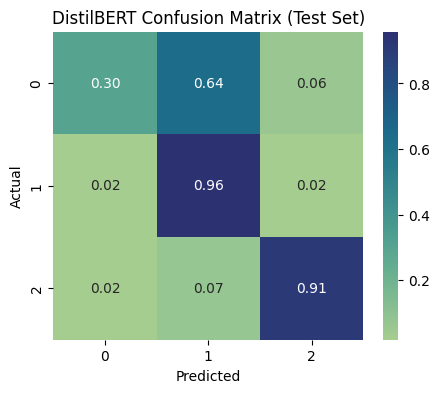

In [131]:
cm = confusion_matrix(y_true, y_pred, normalize='true')

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, cmap='crest', fmt=".2f")
plt.title("DistilBERT Confusion Matrix (Test Set)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
